## INSA — Índice de Desempenho do Saneamento Ambiental

Reprodução da metodologia de Paz et al. (2025) aplicada aos municípios de Minas Gerais, com base no `Mun_Final.csv`.

**Adaptações:**
- `Ca007_taxa` = `CA007 - Quantidade de associados` ÷ `POP_URB` × 10.000 hab.
- `QD004_taxa` = `QD004 - Quantidade de economias ativas atingidas por paralisações` ÷ `AG003 - Quantidade de economias ativas de água` × 100 (%)

In [1]:
import pandas as pd
import numpy as np

# ── 1. Carrega Mun_Final (dados consolidados de Água/Esgoto/Resíduos Sólidos) ───────────────
df_mun = pd.read_csv(
    'Indicadores_Municipais.csv', sep=';', encoding='utf-16', decimal=',',
    thousands='.', index_col=False
)
df_mun['Ano de Referência'] = df_mun['Ano de Referência'].astype(int)
df_mun['Código do IBGE'] = df_mun['Código do IBGE'].astype('Int64')
df_mun['Código do IBGE'] = (
    df_mun.groupby('Código do Município')['Código do IBGE']
    .transform(lambda x: x.ffill().bfill())
)
df_mun = df_mun.drop(columns=[
    'Código do Município','Estado'
])
df_mun

,Código do IBGE,Município,Ano de Referência,Prestadores,Serviços,Natureza Jurídica,POP_TOT - População total do município (Fonte: IBGE):,POP_URB - População urbana do município (Fonte: IBGE),AG003 - Quantidade de economias ativas de água,QD004 - Quantidade de economias ativas atingidas por paralisações,...,IN015_RS - Taxa de cobertura regular do serviço de coleta de rdo em relação à população total do município,IN018_RS - Produtividade média dos empregados na coleta (coletadores + motoristas) na coleta (rdo + rpu) em relação à massa coletada,IN019_RS - Taxa de empregados (coletadores + motoristas) na coleta (rdo + rpu) em relação à população urbana,IN028_RS - Massa de resíduos domiciliares e públicos (rdo+rpu) coletada per capita em relação à população total atendida pelo serviço de coleta,IN030_RS - Taxa de cobertura do serviço de coleta seletiva porta-a-porta em relação à população urbana do município.,IN031_RS - Taxa de recuperação de materiais recicláveis (exceto matéria orgânica e rejeitos) em relação à quantidade total (rdo + rpu) coletada,IN044_RS - Produtividade média dos varredores (prefeitura + empresas contratadas),IN045_RS - Taxa de varredores em relação à população urbana,IN048_RS - Extensão total anual varrida per capita,IN051_RS - Taxa de capinadores em relação à população urbana
0,3100104,Abadia dos Dourados,2022,[31062000] Companhia de Saneamento de Minas Ge...,Água | Res. Sólidos,Sociedade de economia mista com administração ...,6272,NaN,2460.0,0.0,...,93.27,NaN,NaN,0.18,NaN,22.22,NaN,NaN,NaN,NaN
1,3100104,Abadia dos Dourados,2021,[31062000] Companhia de Saneamento de Minas Ge...,Água | Res. Sólidos,Sociedade de economia mista com administração ...,7022,4388.0,2439.0,0.0,...,62.49,NaN,NaN,0.88,100.0,4.49,NaN,NaN,NaN,NaN
2,3100104,Abadia dos Dourados,2020,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água,Administração pública direta | Sociedade de ec...,7006,4378.0,2368.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3100104,Abadia dos Dourados,2019,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água,Administração pública direta | Sociedade de ec...,6989,4367.0,2304.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3100104,Abadia dos Dourados,2018,[31001011] Prefeitura Municipal de Abadia dos ...,Esgotos | Água | Res. Sólidos,NaN,6972,4356.0,2282.0,0.0,...,67.41,NaN,NaN,0.41,NaN,7.14,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5113,3172202,Wenceslau Braz,2021,[31062000] Companhia de Saneamento de Minas Ge...,Água | Res. Sólidos,Sociedade de economia mista com administração ...,2543,1265.0,531.0,0.0,...,25.56,NaN,NaN,0.21,NaN,NaN,NaN,NaN,NaN,NaN
5114,3172202,Wenceslau Braz,2020,[31062000] Companhia de Saneamento de Minas Ge...,Água | Res. Sólidos,Sociedade de economia mista com administração ...,2548,1268.0,535.0,0.0,...,49.76,543.13,1.58,0.73,NaN,NaN,NaN,1.58,NaN,7.89
5115,3172202,Wenceslau Braz,2019,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água,Administração pública direta | Sociedade de ec...,2552,1270.0,528.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5116,3172202,Wenceslau Braz,2018,[31062000] Companhia de Saneamento de Minas Ge...,Água,NaN,2558,1272.0,523.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# ── 2. Carrega indicadores pluviais ────────────────────────────────────────
df_pluviais = pd.read_csv(
    'Indicadores_Pluviais.csv', sep=';', encoding='utf-16-le',
    decimal=',', thousands='.', index_col=False
)

df_pluviais = df_pluviais.drop(columns=[
    'Código do Município','Microrregião','Código da Mesorregião','Natureza Jurídica','Setor Responsável',
    'Capital','UF','Código do Estado','Estado','Código da Região','Região','População Total','População Urbana',
    'Código da Microrregião','Nome do Município','Faixa Populacional','Latitude','Longitude','Área [km^2]'
])
df_pluviais.rename(columns={'Ano de Refererência':'Ano de Referência','Código IBGE':'Código do IBGE'}, inplace=True)
df_pluviais['Código do IBGE'] = df_pluviais['Código do IBGE'].astype('Int64')
df_pluviais

,Ano de Referência,Código do IBGE,Descrição Faixa,IN049 - Investimento per capita em drenagem e Manejo de Águas Pluviais Urbanas,IN040 - Parcela de Domicílios em Situação de Risco de Inundação,IN020 - Taxa de Cobertura de Pavimentação e Meio-Fio na Área Urbana do Município,IN021 - Taxa de cobertura de vias públicas com redes ou canais pluviais subterrâneos na área urbana,IN051 - Densidade de captações de águas pluviais na área urbana
0,2022,3100104,1 - De 1 até 30.000 hab.,NaN,0.0,91.7,100.0,72.0
1,2018,3100104,1 - De 1 até 30.000 hab.,6.89,0.0,100.0,68.2,7.0
2,2017,3100104,1 - De 1 até 30.000 hab.,0.00,0.0,66.7,50.8,19.0
3,2022,3100203,1 - De 1 até 30.000 hab.,NaN,3.3,26.3,63.2,110.0
4,2021,3100203,1 - De 1 até 30.000 hab.,455.05,0.7,73.4,18.0,1.0
...,...,...,...,...,...,...,...,...
4010,2018,3172103,1 - De 1 até 30.000 hab.,0.51,0.0,80.0,60.0,13.0
4011,2022,3172202,1 - De 1 até 30.000 hab.,NaN,0.0,11.0,0.0,0.0
4012,2019,3172202,1 - De 1 até 30.000 hab.,0.00,0.0,84.6,28.5,3.0
4013,2018,3172202,1 - De 1 até 30.000 hab.,9.77,0.0,84.6,2.8,2.0


In [3]:
# ── 3. Merge ──────────────────────────────────────────────────────────────────
df_merged = df_mun.merge(
    df_pluviais,
    on=['Ano de Referência','Código do IBGE'], how='outer'
)
df_merged

,Código do IBGE,Município,Ano de Referência,Prestadores,Serviços,Natureza Jurídica,POP_TOT - População total do município (Fonte: IBGE):,POP_URB - População urbana do município (Fonte: IBGE),AG003 - Quantidade de economias ativas de água,QD004 - Quantidade de economias ativas atingidas por paralisações,...,IN044_RS - Produtividade média dos varredores (prefeitura + empresas contratadas),IN045_RS - Taxa de varredores em relação à população urbana,IN048_RS - Extensão total anual varrida per capita,IN051_RS - Taxa de capinadores em relação à população urbana,Descrição Faixa,IN049 - Investimento per capita em drenagem e Manejo de Águas Pluviais Urbanas,IN040 - Parcela de Domicílios em Situação de Risco de Inundação,IN020 - Taxa de Cobertura de Pavimentação e Meio-Fio na Área Urbana do Município,IN021 - Taxa de cobertura de vias públicas com redes ou canais pluviais subterrâneos na área urbana,IN051 - Densidade de captações de águas pluviais na área urbana
0,3100104,Abadia dos Dourados,2017,[31001011] Prefeitura Municipal de Abadia dos ...,Esgotos | Água,NaN,7059,4411.0,2264.0,0.0,...,NaN,NaN,NaN,NaN,1 - De 1 até 30.000 hab.,0.00,0.0,66.7,50.8,19.0
1,3100203,Abaeté,2017,[31062000] Companhia de Saneamento de Minas Ge...,Água e Esgoto,NaN,23611,20504.0,9727.0,0.0,...,NaN,NaN,NaN,NaN,1 - De 1 até 30.000 hab.,0.00,0.0,80.0,0.0,0.0
2,3100302,Abre Campo,2017,[31003011] Serviço Autônomo de Água e Esgoto -...,Água e Esgoto | Res. Sólidos,NaN,13733,7512.0,3113.0,0.0,...,NaN,3.33,NaN,0.27,1 - De 1 até 30.000 hab.,0.00,1.4,88.0,72.0,677.0
3,3100401,Acaiaca,2017,[31004011] Prefeitura Municipal de Acaiaca - P...,Água e Esgoto | Res. Sólidos,NaN,4065,2647.0,1758.0,1310.0,...,NaN,1.51,NaN,1.51,1 - De 1 até 30.000 hab.,0.00,15.9,65.9,0.0,8.0
4,3100500,Açucena,2017,[31062000] Companhia de Saneamento de Minas Ge...,Água,NaN,9997,4675.0,1435.0,0.0,...,NaN,NaN,NaN,NaN,1 - De 1 até 30.000 hab.,8.56,2.8,78.1,46.9,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5113,3171808,Virginópolis,2022,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água | Res. Sólidos,Administração pública direta | Sociedade de ec...,10314,NaN,3045.0,413.0,...,NaN,NaN,NaN,NaN,1 - De 1 até 30.000 hab.,NaN,3.4,92.0,21.8,27.0
5114,3171907,Virgolândia,2022,[31062000] Companhia de Saneamento de Minas Ge...,Água,Sociedade de economia mista com administração ...,4552,NaN,1636.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5115,3172004,Visconde do Rio Branco,2022,[31062000] Companhia de Saneamento de Minas Ge...,Água e Esgoto | Res. Sólidos,Sociedade de economia mista com administração ...,39160,NaN,15580.0,0.0,...,NaN,NaN,NaN,NaN,2 - De 30.001 até 100.000 hab.,NaN,34.2,96.3,89.1,10.0
5116,3172103,Volta Grande,2022,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água | Res. Sólidos,Administração pública direta | Sociedade de ec...,4443,NaN,1880.0,0.0,...,NaN,NaN,NaN,NaN,1 - De 1 até 30.000 hab.,NaN,2.9,76.9,76.9,38.0


In [4]:
# ── Diagnóstico: NaNs e Zeros em df_merged ───────────────────────────────────
num_cols_diag = df_merged.select_dtypes(include='number').columns.tolist()
n = len(df_merged)

diag = pd.DataFrame({
    'NaN (n)':   df_merged[num_cols_diag].isna().sum(),
    'NaN (%)':   (df_merged[num_cols_diag].isna().mean() * 100).round(1),
    'Zero (n)':  (df_merged[num_cols_diag] == 0).sum(),
    'Zero (%)':  ((df_merged[num_cols_diag] == 0).mean() * 100).round(1),
})
diag.index.name = 'Coluna'
print(f'Total de linhas: {n}')
diag.sort_values('NaN (%)', ascending=False)

Total de linhas: 5118


,NaN (n),NaN (%),Zero (n),Zero (%)
Coluna,,,,
IN044_RS - Produtividade média dos varredores (prefeitura + empresas contratadas),4561,89.1,0,0.0
IN048_RS - Extensão total anual varrida per capita,4527,88.5,22,0.4
IN030_RS - Taxa de cobertura do serviço de coleta seletiva porta-a-porta em relação à população urbana do município.,4279,83.6,0,0.0
IN011_RS - Receita arrecadada per capita com taxas ou outras formas de cobrança pela prestação de serviços de manejo rsu,3705,72.4,42,0.8
IN005_RS - Auto-suficiência financeira da prefeitura com o manejo de rsu,3395,66.3,41,0.8
IN031_RS - Taxa de recuperação de materiais recicláveis (exceto matéria orgânica e rejeitos) em relação à quantidade total (rdo + rpu) coletada,3334,65.1,0,0.0
IN072_AE - Duração média das paralisações,3106,60.7,0,0.0
IN051_RS - Taxa de capinadores em relação à população urbana,2713,53.0,316,6.2
IN019_RS - Taxa de empregados (coletadores + motoristas) na coleta (rdo + rpu) em relação à população urbana,2712,53.0,17,0.3


In [5]:
# ── Diagnóstico: NaNs e Zeros em df_merged ───────────────────────────────────
num_cols_diag = df_merged.select_dtypes(include='number').columns.tolist()
n = len(df_merged)

diag = pd.DataFrame({
    'NaN (n)':   df_merged[num_cols_diag].isna().sum(),
    'NaN (%)':   (df_merged[num_cols_diag].isna().mean() * 100).round(1),
    'Zero (n)':  (df_merged[num_cols_diag] == 0).sum(),
    'Zero (%)':  ((df_merged[num_cols_diag] == 0).mean() * 100).round(1),
})
diag.index.name = 'Coluna'
print(f'Total de linhas: {n}')
diag.sort_values('NaN (%)', ascending=False)

Total de linhas: 5118


,NaN (n),NaN (%),Zero (n),Zero (%)
Coluna,,,,
IN044_RS - Produtividade média dos varredores (prefeitura + empresas contratadas),4561,89.1,0,0.0
IN048_RS - Extensão total anual varrida per capita,4527,88.5,22,0.4
IN030_RS - Taxa de cobertura do serviço de coleta seletiva porta-a-porta em relação à população urbana do município.,4279,83.6,0,0.0
IN011_RS - Receita arrecadada per capita com taxas ou outras formas de cobrança pela prestação de serviços de manejo rsu,3705,72.4,42,0.8
IN005_RS - Auto-suficiência financeira da prefeitura com o manejo de rsu,3395,66.3,41,0.8
IN031_RS - Taxa de recuperação de materiais recicláveis (exceto matéria orgânica e rejeitos) em relação à quantidade total (rdo + rpu) coletada,3334,65.1,0,0.0
IN072_AE - Duração média das paralisações,3106,60.7,0,0.0
IN051_RS - Taxa de capinadores em relação à população urbana,2713,53.0,316,6.2
IN019_RS - Taxa de empregados (coletadores + motoristas) na coleta (rdo + rpu) em relação à população urbana,2712,53.0,17,0.3


In [6]:
# ── 4. Ano mais recente por município ────────────────────────────────────────
# Filtra apenas o ano de 2020
df_latest = df_merged[df_merged['Ano de Referência'] == 2020].copy()
# ── 5. Ca007: quantidade → taxa por 10.000 hab. urbanos ──────────────────────
pop_urb = df_latest['POP_URB - População urbana do município (Fonte: IBGE)'].replace(0, np.nan)
df_latest['Ca007_taxa'] = df_latest['CA007 - Quantidade de associados'] / pop_urb * 10000

# ── 6. QD004: quantidade → % de economias ativas atingidas ──────────────────
# Denominador correto: AG003 - Quantidade de economias ativas de água
ag003 = df_latest['AG003 - Quantidade de economias ativas de água'].replace(0, np.nan)
df_latest['QD004_taxa'] = (
    df_latest['QD004 - Quantidade de economias ativas atingidas por paralisações'] / ag003 * 100
)

print(f'\nCa007_taxa — descritiva:\n{df_latest["Ca007_taxa"].describe().round(2)}')
print(f'\nQD004_taxa (%) — descritiva:\n{df_latest["QD004_taxa"].describe().round(2)}')


Ca007_taxa — descritiva:
count    728.00
mean       2.15
std        6.79
min        0.00
25%        0.00
50%        0.00
75%        0.00
max       91.20
Name: Ca007_taxa, dtype: float64

QD004_taxa (%) — descritiva:
count      700.00
mean        75.42
std        556.15
min          0.00
25%          0.00
50%          0.00
75%         38.77
max      14153.85
Name: QD004_taxa, dtype: float64


In [7]:
# ── 7. Mapeamento das colunas para os códigos do artigo ──────────────────────
indicadores = {
    # Abastecimento de Água
    'IN055':    'IN055_AE - Índice de atendimento total de água',
    'IN011_AE': 'IN011_AE - Índice de macromedição',
    'IN009':    'IN009_AE - Índice de hidrometração',
    'IN025':    'IN025_AE - Volume de água disponibilizado por economia',
    'IN058':    'IN058_AE - Índice de consumo de energia elétrica em sistemas de abastecimento de água',
    'IN013':    'IN013_AE - Índice de perdas faturamento',
    'IN049_AE': 'IN049_AE - Índice de perdas na distribuição',
    'IN085':    'IN085_AE - Índice de conformidade da quantidade de amostras - coliformes totais',
    'QD004':    'QD004_taxa',   # derivada: QD004 / AG003 * 100
    'IN072':    'IN072_AE - Duração média das paralisações',
    # Esgotamento Sanitário
    'IN056':    'IN056_AE - Índice de atendimento total de esgoto referido aos municípios atendidos com água',
    'IN015_AE': 'IN015_AE - Índice de coleta de esgoto',
    'IN021_AE': 'IN021_AE - Extensão da rede de esgoto por ligação',
    'IN059':    'IN059_AE - Índice de consumo de energia elétrica em sistemas de esgotamento sanitário',
    'IN077':    'IN077_AE - Duração média dos reparos de extravasamentos de esgotos',
    'IN082':    'IN082_AE - Extravasamentos de esgotos por extensão de rede',
    # Resíduos Sólidos
    'IN005_RS': 'IN005_RS - Auto-suficiência financeira da prefeitura com o manejo de rsu',
    'IN011_RS': 'IN011_RS - Receita arrecadada per capita com taxas ou outras formas de cobrança pela prestação de serviços de manejo rsu',
    'IN015_RS': 'IN015_RS - Taxa de cobertura regular do serviço de coleta de rdo em relação à população total do município',
    'IN018_RS': 'IN018_RS - Produtividade média dos empregados na coleta (coletadores + motoristas) na coleta (rdo + rpu) em relação à massa coletada',
    'IN019_RS': 'IN019_RS - Taxa de empregados (coletadores + motoristas) na coleta (rdo + rpu) em relação à população urbana',
    'IN028_RS': 'IN028_RS - Massa de resíduos domiciliares e públicos (rdo+rpu) coletada per capita em relação à população total atendida pelo serviço de coleta',
    'IN030_RS': 'IN030_RS - Taxa de cobertura do serviço de coleta seletiva porta-a-porta em relação à população urbana do município.',
    'IN031_RS': 'IN031_RS - Taxa de recuperação de materiais recicláveis (exceto matéria orgânica e rejeitos) em relação à quantidade total (rdo + rpu) coletada',
    'IN044_RS': 'IN044_RS - Produtividade média dos varredores (prefeitura + empresas contratadas)',
    'IN045_RS': 'IN045_RS - Taxa de varredores em relação à população urbana',
    'IN048_RS': 'IN048_RS - Extensão total anual varrida per capita',
    'IN051_RS': 'IN051_RS - Taxa de capinadores em relação à população urbana',
    'Ca007':    'Ca007_taxa',  # derivada: CA007 / POP_URB * 10000
    # Drenagem
    'IN049_DR': 'IN049 - Investimento per capita em drenagem e Manejo de Águas Pluviais Urbanas',
    'IN020':    'IN020 - Taxa de Cobertura de Pavimentação e Meio-Fio na Área Urbana do Município',
    'IN021_DR': 'IN021 - Taxa de cobertura de vias públicas com redes ou canais pluviais subterrâneos na área urbana',
    'IN051_DR': 'IN051 - Densidade de captações de águas pluviais na área urbana',
    'IN040':    'IN040 - Parcela de Domicílios em Situação de Risco de Inundação',
}

faltando = [v for v in indicadores.values() if v not in df_latest.columns]
if faltando:
    print('ATENÇÃO — colunas não encontradas:')
    for c in faltando: print(' ', c)
else:
    print('Todas as colunas encontradas.')

# DataFrame de trabalho com nomes curtos
df_work = df_latest[[
    'Código do IBGE','Município','Ano de Referência','Descrição Faixa',
    'Prestadores','Serviços','Natureza Jurídica',
    'POP_TOT - População total do município (Fonte: IBGE):',
    'POP_URB - População urbana do município (Fonte: IBGE)'
]].copy()
df_work.columns = ['IBGE','Município','Ano','Descrição Faixa',
                   'Prestadores','Serviços','Natureza Jurídica','POP_TOT','POP_URB']
for cod, col in indicadores.items():
    if col in df_latest.columns:
        df_work[cod] = df_latest[col].values

# ── 8. Quartis ───────────────────────────────────────────────────────────────
cols_ind = [c for c in indicadores if c in df_work.columns]
quartis = df_work[cols_ind].quantile([0.25, 0.50, 0.75])
quartis.index = ['Q1','Q2','Q3']
print('\nQuartis dos indicadores:')
quartis.T


Todas as colunas encontradas.

Quartis dos indicadores:


,Q1,Q2,Q3
IN055,54.6100,69.410,82.670000
IN011_AE,83.8200,100.000,100.000000
IN009,99.9700,100.000,100.000000
IN025,10.9000,12.500,15.700000
IN058,0.5400,0.740,0.960000
IN013,20.2500,27.260,35.570000
IN049_AE,19.7300,26.510,34.470000
IN085,100.0000,110.490,124.670000
QD004,0.0000,0.000,38.769356
IN072,7.3150,9.230,12.867500


In [8]:
# ── 9. Score 0/1/3/5 por quartil ─────────────────────────────────────────────
reducao = {'IN058','IN013','IN049_AE','QD004','IN072',
           'IN059','IN077','IN082','IN040'}

def score_indicador(series, q1, q2, q3, reduzir=False):
    s = pd.Series(np.nan, index=series.index, dtype=float)
    if not reduzir:
        s[series > q3]                    = 5
        s[(series > q2) & (series <= q3)] = 3
        s[(series > q1) & (series <= q2)] = 1
        s[series <= q1]                   = 0
    else:
        s[series < q1]                    = 5
        s[(series >= q1) & (series < q2)] = 3
        s[(series >= q2) & (series < q3)] = 1
        s[series >= q3]                   = 0
    s[series.isna()]                      = np.nan
    return s

for cod in cols_ind:
    q1, q2, q3 = quartis.loc['Q1', cod], quartis.loc['Q2', cod], quartis.loc['Q3', cod]
    df_work[f'S_{cod}'] = score_indicador(df_work[cod], q1, q2, q3, reduzir=cod in reducao)

print('Scores calculados:', sum(1 for c in df_work.columns if c.startswith('S_')))

# ── 10. Pesos AHP (Tabelas 3-6 do artigo) ────────────────────────────────────
pesos_aa = {
    'IN055':0.216,'IN011_AE':0.157,'IN009':0.194,'IN025':0.056,
    'IN058':0.018,'IN013':0.111,'IN049_AE':0.111,'IN085':0.042,
    'QD004':0.077,'IN072':0.019
}
pesos_es = {
    'IN056':0.263,'IN015_AE':0.263,'IN021_AE':0.024,
    'IN059':0.065,'IN077':0.131,'IN082':0.254
}
pesos_rs = {
    'IN005_RS':0.166,'IN011_RS':0.096,'IN015_RS':0.146,'IN018_RS':0.052,
    'IN019_RS':0.029,'IN028_RS':0.081,'IN030_RS':0.116,'IN031_RS':0.158,
    'IN044_RS':0.055,'IN045_RS':0.032,'IN048_RS':0.052,'IN051_RS':0.019,
    'Ca007':0.116
}
pesos_dr = {
    'IN049_DR':0.046,'IN020':0.124,'IN021_DR':0.124,
    'IN051_DR':0.277,'IN040':0.427
}


Scores calculados: 34


In [9]:
# ── 11. Sub-índices e INSA (Eq. 1-5 do artigo) ───────────────────────────────
def subindice(df, pesos, max_score=5):
    """Soma ponderada normalizada em [0,1]. Pesos de indicadores ausentes são excluídos."""
    total = pd.Series(0.0, index=df.index)
    peso_valido = pd.Series(0.0, index=df.index)
    for cod, peso in pesos.items():
        col = f'S_{cod}'
        if col not in df.columns:
            continue
        valido = df[col].notna()
        total += df[col].fillna(0) * peso
        peso_valido += valido.astype(float) * peso
    resultado = total / (peso_valido * max_score)
    resultado[peso_valido == 0] = np.nan
    return resultado

df_work['IDAA'] = subindice(df_work, pesos_aa)
df_work['IDES'] = subindice(df_work, pesos_es)
df_work['IDRS'] = subindice(df_work, pesos_rs)
df_work['IDAP'] = subindice(df_work, pesos_dr)
df_work['INSA'] = df_work[['IDAA','IDES','IDRS','IDAP']].mean(axis=1)

def classifica(v):
    if pd.isna(v):  return 'Sem dados'
    if v < 0.4:     return 'Baixo'
    if v < 0.6:     return 'Médio'
    if v < 0.8:     return 'Alto'
    return 'Excelente'

df_work['Desempenho'] = df_work['INSA'].apply(classifica)

print(f'INSA médio de MG: {df_work["INSA"].mean():.3f}')
print(f'Sub-índices médios:')
for col in ['IDAA','IDES','IDRS','IDAP']:
    print(f'  {col}: {df_work[col].mean():.3f}')
print()
print('Distribuição por desempenho:')
print(df_work['Desempenho'].value_counts())


INSA médio de MG: 0.366
Sub-índices médios:
  IDAA: 0.321
  IDES: 0.417
  IDRS: 0.382
  IDAP: 0.396

Distribuição por desempenho:
Desempenho
Baixo        512
Médio        311
Alto          18
Sem dados     12
Name: count, dtype: int64


In [10]:
# ── 12. Ranking ──────────────────────────────────────────────────────────────
cols_result = ['Município','IBGE','Descrição Faixa','Prestadores','Serviços',
               'Natureza Jurídica','POP_TOT','POP_URB','Ano',
               'IDAA','IDES','IDRS','IDAP','INSA','Desempenho']
ranking = (
    df_work[cols_result]
    .sort_values('INSA', ascending=False)
    .reset_index(drop=True)
)
ranking.index += 1
ranking.index.name = 'Posição'


# ── Extrai código do primeiro prestador (primeiro colchete) ──────────────────
ranking['Cod_Prestador'] = (
    ranking['Prestadores']
    .str.extract(r'\[(\d+)\]', expand=False)
    .astype('Int64')
)

print('Top 15 municípios de MG por INSA:')
display(ranking.head(15).round(3))

print('\nPiores 10 municípios:')
display(ranking.tail(10).round(3))

ranking.to_csv('ranking_INSA_MG_2020.csv', sep=';', decimal=',', encoding='utf-8-sig')
print('\nExportado: ranking_INSA_MG_2020.csv')

Top 15 municípios de MG por INSA:


,Município,IBGE,Descrição Faixa,Prestadores,Serviços,Natureza Jurídica,POP_TOT,POP_URB,Ano,IDAA,IDES,IDRS,IDAP,INSA,Desempenho,Cod_Prestador
Posição,,,,,,,,,,,,,,,,
1,Nova Ponte,3145000,1 - De 1 até 30.000 hab.,[31450011] Prefeitura Municipal de Nova Ponte ...,Água e Esgoto | Res. Sólidos,Administração pública direta | Administração p...,15800,13554.0,2020,0.644,0.698,0.490,0.783,0.654,Alto,31450011
2,Carmópolis de Minas,3114501,1 - De 1 até 30.000 hab.,[31145011] Serviço de Saneamento Ambiental Mun...,Água e Esgoto | Res. Sólidos,Autarquia | Autarquia,19559,13562.0,2020,0.484,0.741,0.774,0.605,0.651,Alto,31145011
3,Poços de Caldas,3151800,3 - De 100.001 até 250.000 hab.,[31518011] Departamento Municipal de Água e Es...,Água e Esgoto | Res. Sólidos,Autarquia | Administração pública direta,168641,164533.0,2020,0.375,0.833,0.730,0.636,0.644,Alto,31518011
4,Itaú de Minas,3133758,1 - De 1 até 30.000 hab.,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água | Res. Sólidos,Administração pública direta | Sociedade de ec...,16199,15784.0,2020,0.406,0.696,0.716,0.711,0.632,Alto,31062000
5,Olímpio Noronha,3145505,1 - De 1 até 30.000 hab.,[31455011] Prefeitura Municipal de Olímpio Nor...,Água e Esgoto | Res. Sólidos,Administração pública direta | Administração p...,2809,2494.0,2020,0.566,0.821,0.469,0.659,0.629,Alto,31455011
6,Itanhandu,3133105,1 - De 1 até 30.000 hab.,[31331011] Prefeitura Municipal de Itanhandu -...,Água e Esgoto | Res. Sólidos,Administração pública direta | Administração p...,15423,12975.0,2020,0.530,0.755,0.728,0.476,0.623,Alto,31331011
7,Sacramento,3156908,1 - De 1 até 30.000 hab.,[31569011] Serviço Autônomo de Água e Esgoto d...,Água e Esgoto | Res. Sólidos,Autarquia | Administração pública direta,26374,21274.0,2020,0.539,0.666,0.543,0.733,0.620,Alto,31569011
8,Alterosa,3102001,1 - De 1 até 30.000 hab.,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água,Administração pública direta | Sociedade de ec...,14517,10585.0,2020,0.363,0.713,NaN,0.783,0.620,Alto,31062000
9,São Bento Abade,3160801,1 - De 1 até 30.000 hab.,[31062000] Companhia de Saneamento de Minas Ge...,Esgotos | Água | Res. Sólidos,Administração pública direta | Sociedade de ec...,5349,4953.0,2020,0.542,0.821,0.393,0.711,0.617,Alto,31062000



Piores 10 municípios:


,Município,IBGE,Descrição Faixa,Prestadores,Serviços,Natureza Jurídica,POP_TOT,POP_URB,Ano,IDAA,IDES,IDRS,IDAP,INSA,Desempenho,Cod_Prestador
Posição,,,,,,,,,,,,,,,,
844,Doresópolis,3123403,NaN,NaN,NaN,NaN,1533,1205.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
845,Galiléia,3127305,NaN,NaN,NaN,NaN,6790,5560.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
846,Inhaúma,3131000,NaN,NaN,NaN,NaN,6312,4609.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
847,Natalândia,3144375,NaN,NaN,NaN,NaN,3308,2492.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
848,Paiva,3146602,NaN,NaN,NaN,NaN,1523,1192.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
849,Romaria,3156403,NaN,NaN,NaN,NaN,3520,2658.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
850,Santa Bárbara do Monte Verde,3157278,NaN,NaN,NaN,NaN,3182,1838.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
851,Sem-Peixe,3165560,NaN,NaN,NaN,NaN,2606,1379.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>
852,Serranos,3167004,NaN,NaN,NaN,NaN,1956,1513.0,2020,NaN,NaN,NaN,NaN,NaN,Sem dados,<NA>



Exportado: ranking_INSA_MG_2020.csv


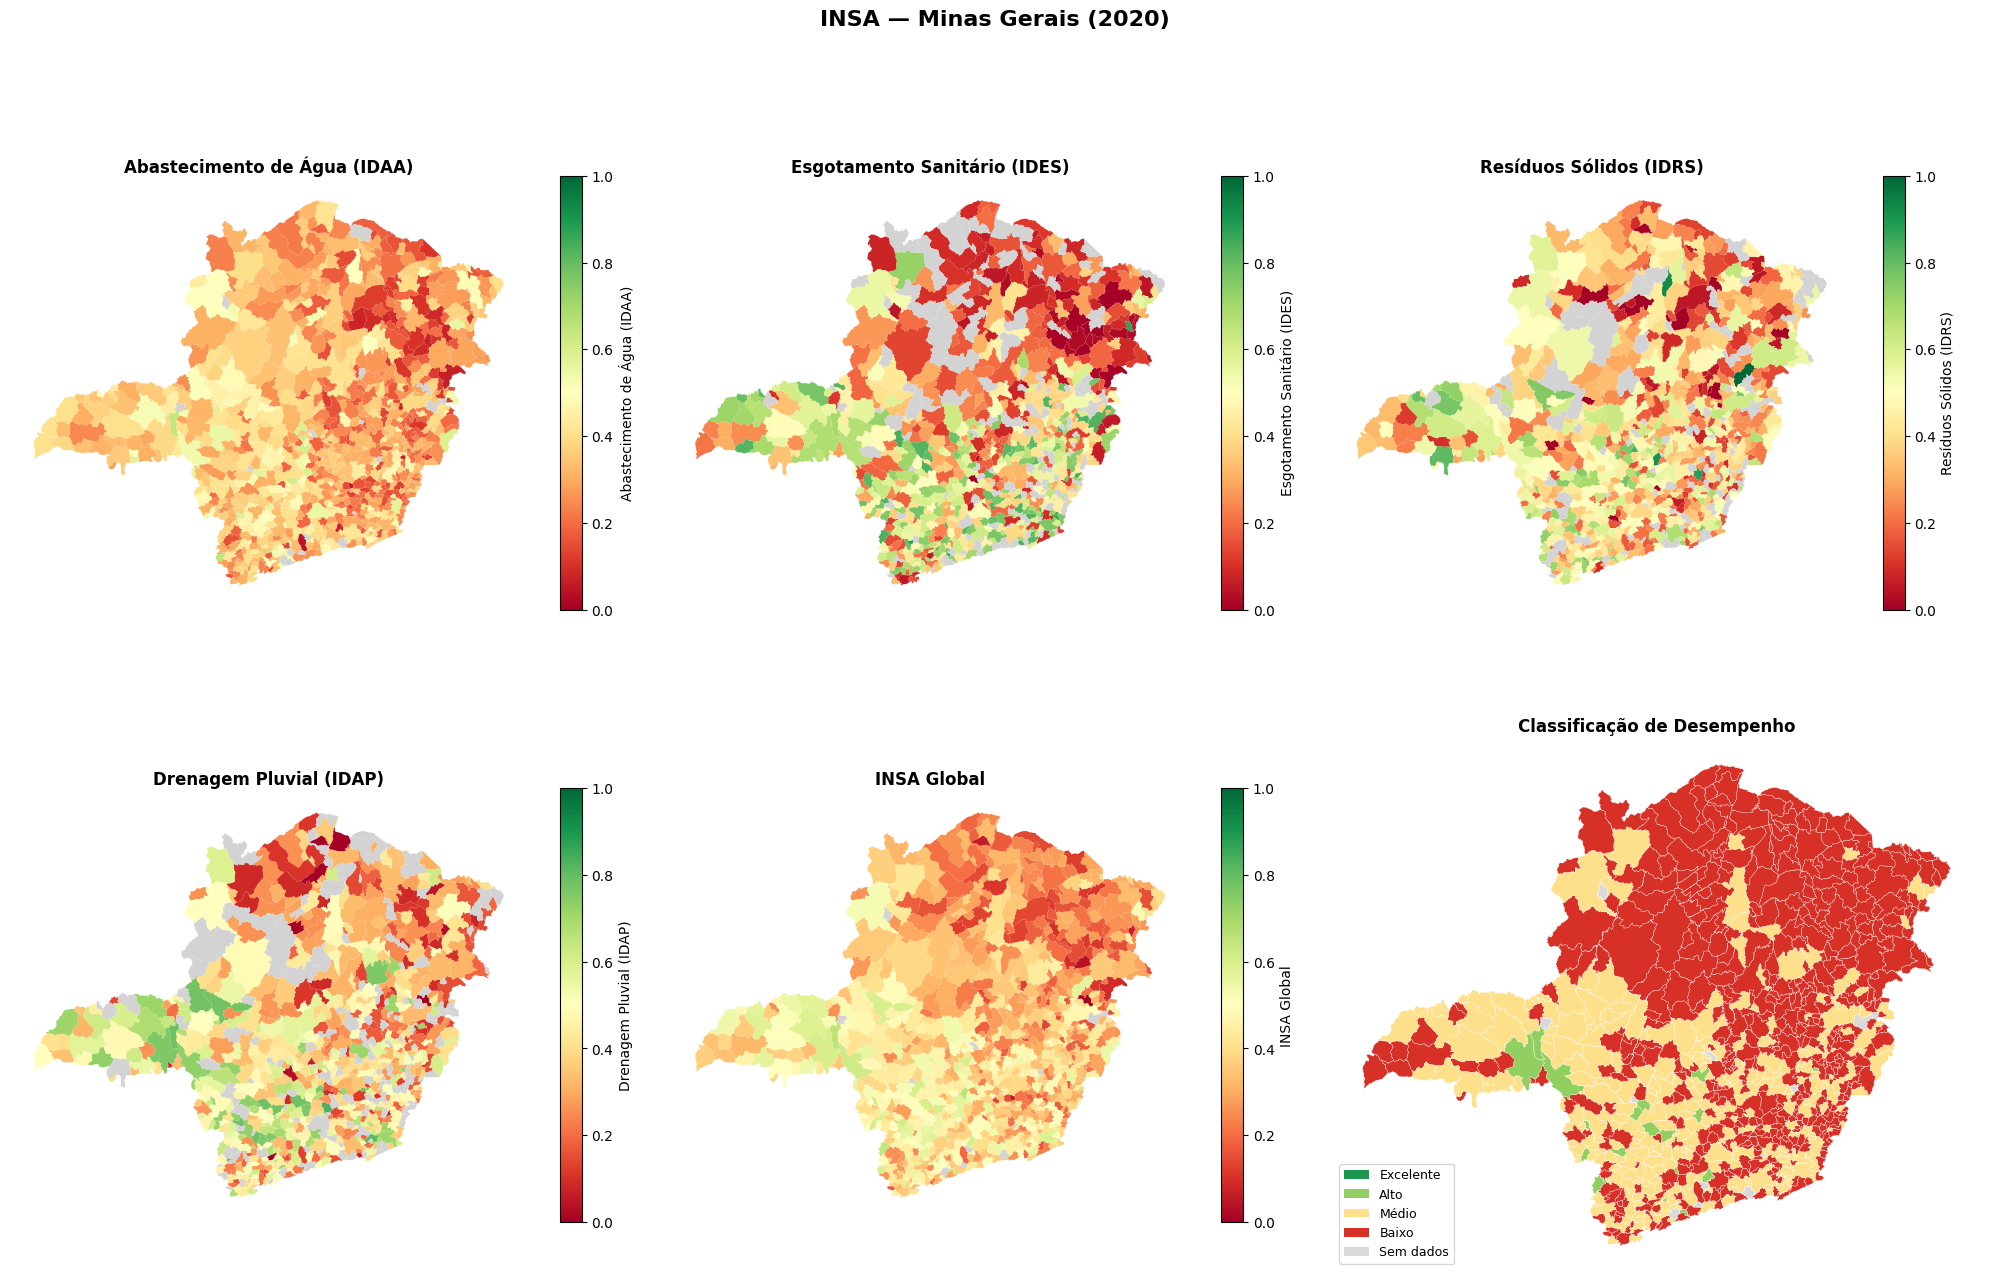

In [11]:
# ── 13. Mapeamento dos índices ────────────────────────────────────────────────
import geopandas as gpd
import geobr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Malha municipal de MG (IBGE 2020)
mun_mg = geobr.read_municipality(code_muni='MG', year=2020)
mun_mg['code_muni'] = mun_mg['code_muni'].astype('Int64')

# Merge com os resultados
geo = mun_mg.merge(df_work, left_on='code_muni', right_on='IBGE', how='left')

# ── Mapa dos sub-índices + INSA ──────────────────────────────────────────────
variaveis = ['IDAA', 'IDES', 'IDRS', 'IDAP', 'INSA']
titulos = [
    'Abastecimento de Água (IDAA)',
    'Esgotamento Sanitário (IDES)',
    'Resíduos Sólidos (IDRS)',
    'Drenagem Pluvial (IDAP)',
    'INSA Global'
]

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

cmap = plt.cm.RdYlGn  # vermelho (ruim) → verde (bom)

for i, (var, titulo) in enumerate(zip(variaveis, titulos)):
    ax = axes[i]
    geo.plot(
        column=var, ax=ax, cmap=cmap,
        legend=True, vmin=0, vmax=1,
        missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'},
        legend_kwds={'shrink': 0.6, 'label': titulo}
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.axis('off')

# Mapa categórico de Desempenho
ax = axes[5]
cores_desemp = {'Excelente': '#1a9850', 'Alto': '#91cf60', 'Médio': '#fee08b', 'Baixo': '#d73027', 'Sem dados': '#d9d9d9'}
geo['cor_desemp'] = geo['Desempenho'].map(cores_desemp).fillna('#d9d9d9')
geo.plot(color=geo['cor_desemp'], ax=ax, edgecolor='white', linewidth=0.2)
# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in cores_desemp.items()]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
ax.set_title('Classificação de Desempenho', fontsize=12, fontweight='bold')
ax.axis('off')

plt.suptitle('INSA — Minas Gerais (2020)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

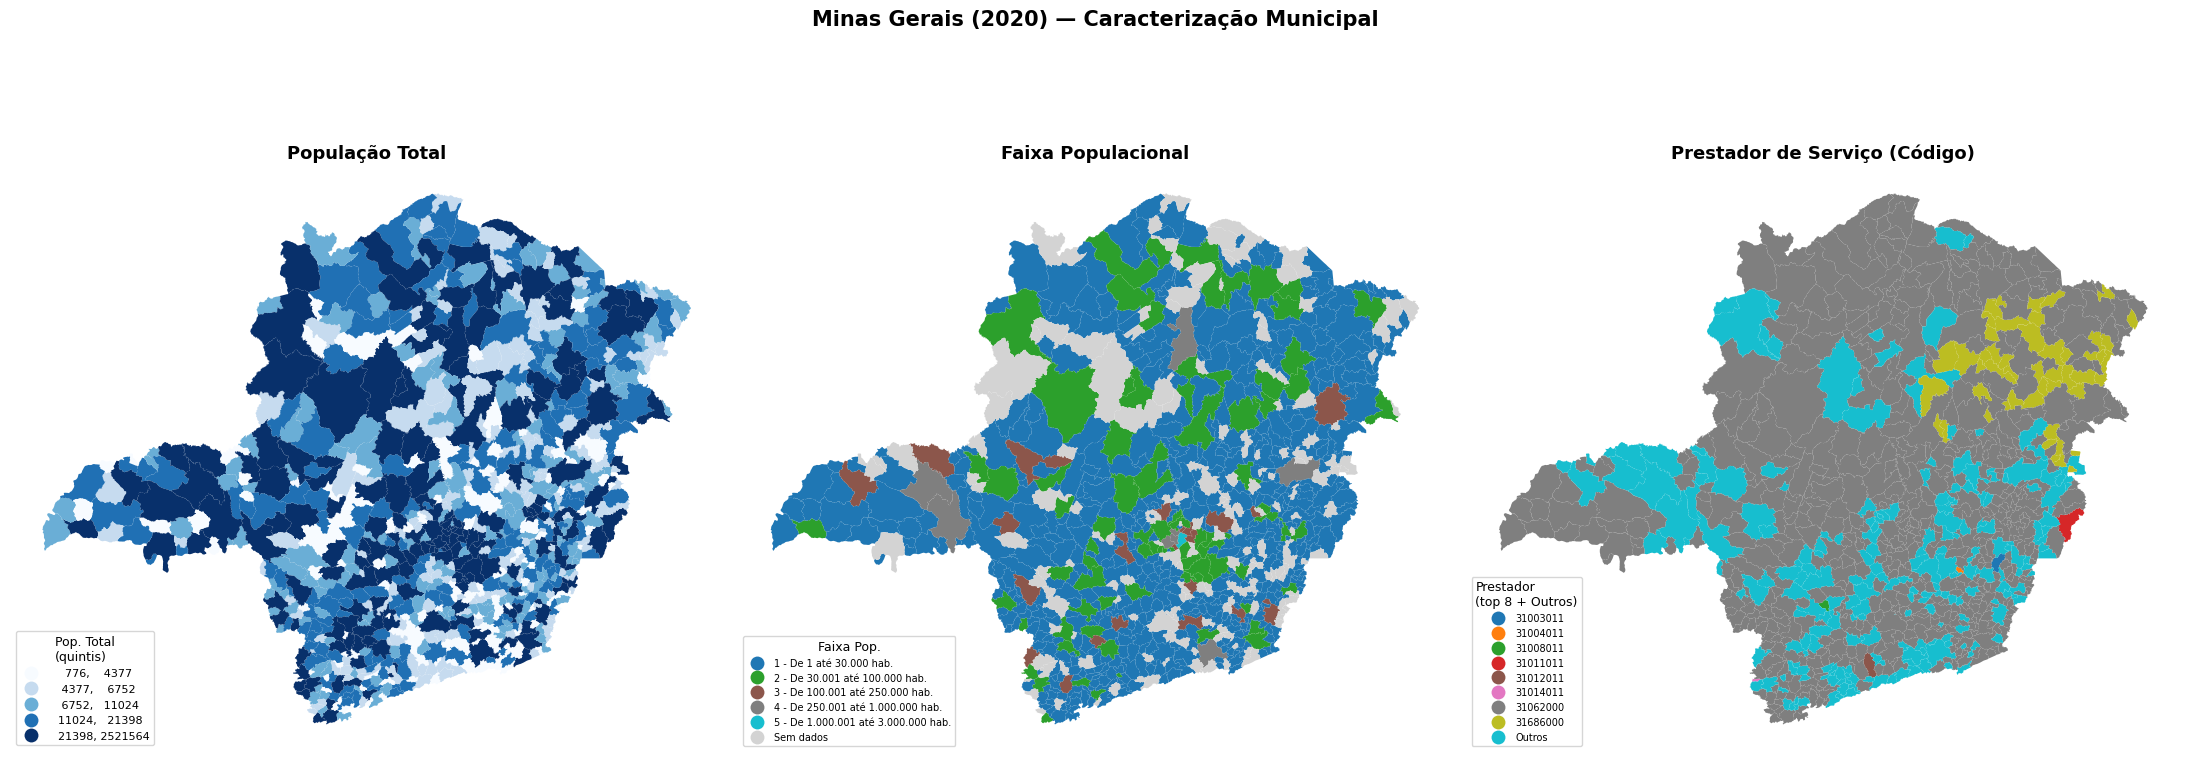


Códigos no mapa (top 8):
Cod_Prestador
31062000    582
31686000     48
31003011      1
31004011      1
31008011      1
31011011      1
31012011      1
31014011      1


In [12]:
# ── 14. Mapas de caracterização: Cod_Prestador, POP_TOT, Descrição Faixa ─────
import geopandas as gpd
import geobr
import matplotlib.pyplot as plt
import numpy as np

# Malha municipal de MG
mun_mg2 = geobr.read_municipality(code_muni='MG', year=2020)
mun_mg2['code_muni'] = mun_mg2['code_muni'].astype('Int64')

# Adiciona Cod_Prestador ao df_work
df_map = df_work[['IBGE','Município','POP_TOT','Descrição Faixa','Prestadores']].copy()
df_map['Cod_Prestador'] = (
    df_map['Prestadores']
    .str.extract(r'\[(\d+)\]', expand=False)
)

# Agrupa prestadores menores como "Outros" (mantém apenas os top N por nº de municípios)
TOP_N = 8
top_prest = df_map['Cod_Prestador'].value_counts().head(TOP_N).index
df_map['Prestador_cat'] = df_map['Cod_Prestador'].where(
    df_map['Cod_Prestador'].isin(top_prest), other='Outros'
).fillna('Sem dados')

geo2 = mun_mg2.merge(df_map, left_on='code_muni', right_on='IBGE', how='left')
geo2['Prestador_cat'] = geo2['Prestador_cat'].fillna('Sem dados')

fig, axes = plt.subplots(1, 3, figsize=(22, 9))

# ── Mapa 1: POP_TOT (quantis) ────────────────────────────────────────────────
geo2.plot(
    column='POP_TOT', ax=axes[0], cmap='Blues',
    scheme='quantiles', k=5, legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'},
    legend_kwds={'title': 'Pop. Total\n(quintis)', 'fontsize': 8, 'title_fontsize': 9,
                 'fmt': '{:.0f}', 'loc': 'lower left'}
)
axes[0].set_title('População Total', fontsize=13, fontweight='bold')
axes[0].axis('off')

# ── Mapa 2: Descrição Faixa (categórico) ─────────────────────────────────────
geo2.plot(
    column='Descrição Faixa', ax=axes[1],
    categorical=True, cmap='tab10', legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'},
    legend_kwds={'loc': 'lower left', 'fontsize': 7, 'title': 'Faixa Pop.', 'title_fontsize': 9}
)
axes[1].set_title('Faixa Populacional', fontsize=13, fontweight='bold')
axes[1].axis('off')

# ── Mapa 3: Prestador (top N + Outros) ───────────────────────────────────────
geo2.plot(
    column='Prestador_cat', ax=axes[2],
    categorical=True, cmap='tab10', legend=True,
    legend_kwds={'loc': 'lower left', 'fontsize': 7, 'title': f'Prestador\n(top {TOP_N} + Outros)',
                 'title_fontsize': 9}
)
axes[2].set_title('Prestador de Serviço (Código)', fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Minas Gerais (2020) — Caracterização Municipal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nCódigos no mapa (top {TOP_N}):')
print(df_map['Cod_Prestador'].value_counts().head(TOP_N).to_string())


In [13]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='libpysal')
# ── 15. Econometria Espacial — Matriz de Pesos (Queen) ───────────────────────
import libpysal
import esda
from splot.esda import moran_scatterplot, plot_local_autocorrelation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# GeoDataFrame apenas com municípios que têm INSA
geo_sp = geo.dropna(subset=['INSA']).copy().reset_index(drop=True)

# Matriz de contiguidade Queen (linha normalizada)
W = libpysal.weights.Queen.from_dataframe(geo_sp, silence_warnings=True)
W.transform = 'r'  # row-standardize

print(f'Municípios na análise: {len(geo_sp)}')
print(f'Média de vizinhos: {W.mean_neighbors:.2f}')
print(f'Ilhas (sem vizinhos): {W.islands}')


/tmp/ipykernel_1118993/3821822861.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W = libpysal.weights.Queen.from_dataframe(geo_sp, silence_warnings=True)


Municípios na análise: 841
Média de vizinhos: 5.48
Ilhas (sem vizinhos): []


/tmp/ipykernel_1118993/1775856314.py:20: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
/tmp/ipykernel_1118993/1775856314.py:20: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
/tmp/ipykernel_1118993/1775856314.py:20: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
/tmp/ipykernel_1118993/1775856314.py:20: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior a

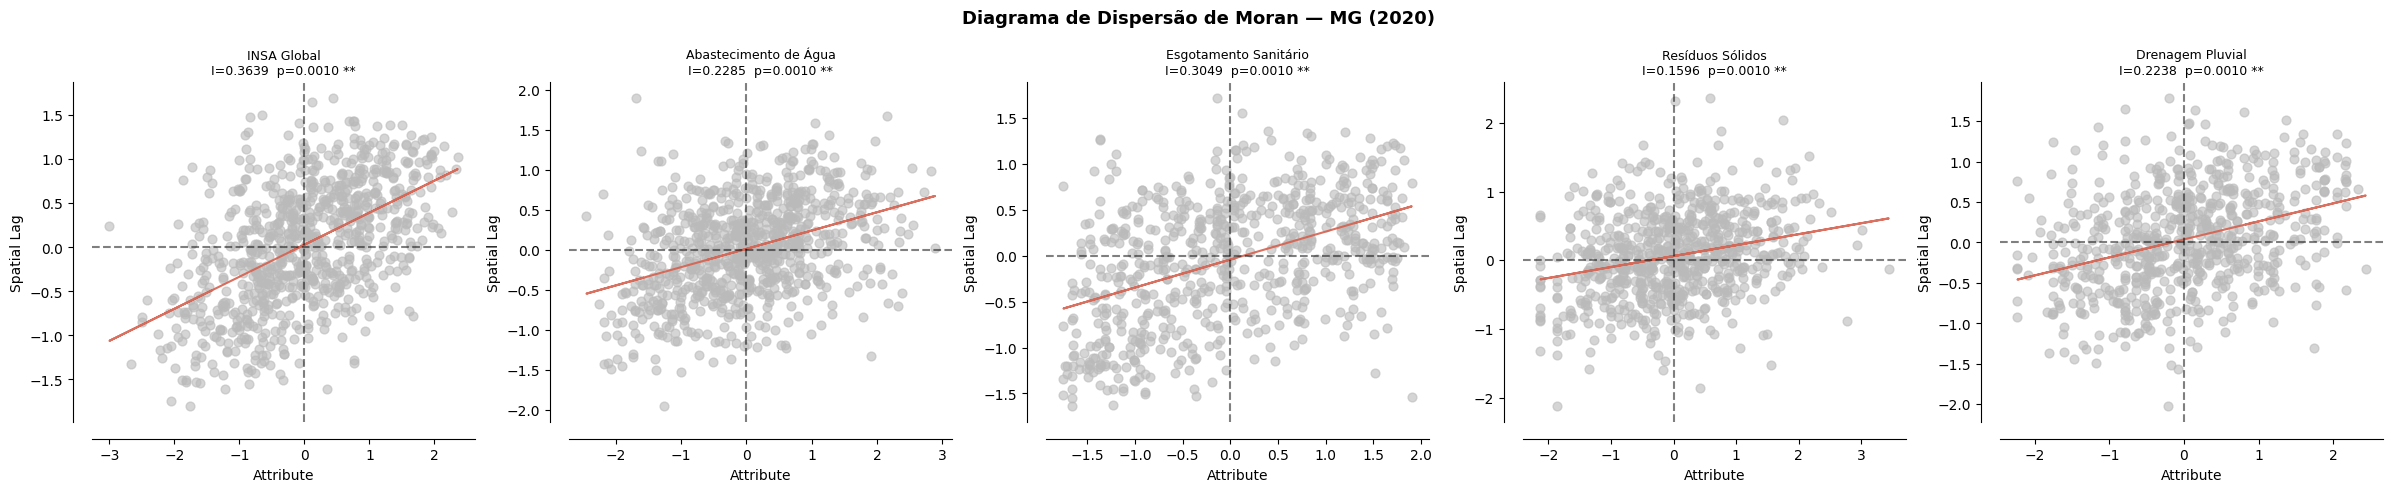


Resultados I de Moran Global (999 permutações):


,Variável,I de Moran,E[I],p-valor (sim.),z-score
0,INSA Global,0.3639,-0.0012,0.001,16.8760
1,Abastecimento de Água,0.2285,-0.0012,0.001,10.5434
2,Esgotamento Sanitário,0.3049,-0.0014,0.001,11.8104
3,Resíduos Sólidos,0.1596,-0.0014,0.001,6.4648
4,Drenagem Pluvial,0.2238,-0.0015,0.001,8.5135


In [14]:
# ── 16. I de Moran Global — INSA e Sub-índices ───────────────────────────────
variaveis_esp = {
    'INSA':  'INSA Global',
    'IDAA':  'Abastecimento de Água',
    'IDES':  'Esgotamento Sanitário',
    'IDRS':  'Resíduos Sólidos',
    'IDAP':  'Drenagem Pluvial',
}

resultados_moran = []
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, (var, titulo) in zip(axes, variaveis_esp.items()):
    # Usa apenas municípios com valor válido para cada sub-índice
    mask = geo_sp[var].notna()
    if mask.sum() < 10:
        ax.set_visible(False)
        continue
    geo_sub = geo_sp[mask].copy().reset_index(drop=True)
    W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
    W_sub.transform = 'r'
    y = geo_sub[var].values
    mi = esda.Moran(y, W_sub, permutations=999)
    resultados_moran.append({
        'Variável': titulo, 'I de Moran': round(mi.I, 4),
        'E[I]': round(mi.EI, 4), 'p-valor (sim.)': round(mi.p_sim, 4),
        'z-score': round(mi.z_norm, 4)
    })
    moran_scatterplot(mi, ax=ax, aspect_equal=False)
    sig = '***' if mi.p_sim < 0.001 else ('**' if mi.p_sim < 0.01 else ('*' if mi.p_sim < 0.05 else 'ns'))
    ax.set_title(f'{titulo}\nI={mi.I:.4f}  p={mi.p_sim:.4f} {sig}', fontsize=9)

plt.suptitle('Diagrama de Dispersão de Moran — MG (2020)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

import pandas as pd
df_moran = pd.DataFrame(resultados_moran)
print('\nResultados I de Moran Global (999 permutações):')
display(df_moran)

/tmp/ipykernel_1118993/2804539635.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
/tmp/ipykernel_1118993/2804539635.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
/tmp/ipykernel_1118993/2804539635.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
/tmp/ipykernel_1118993/2804539635.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior a

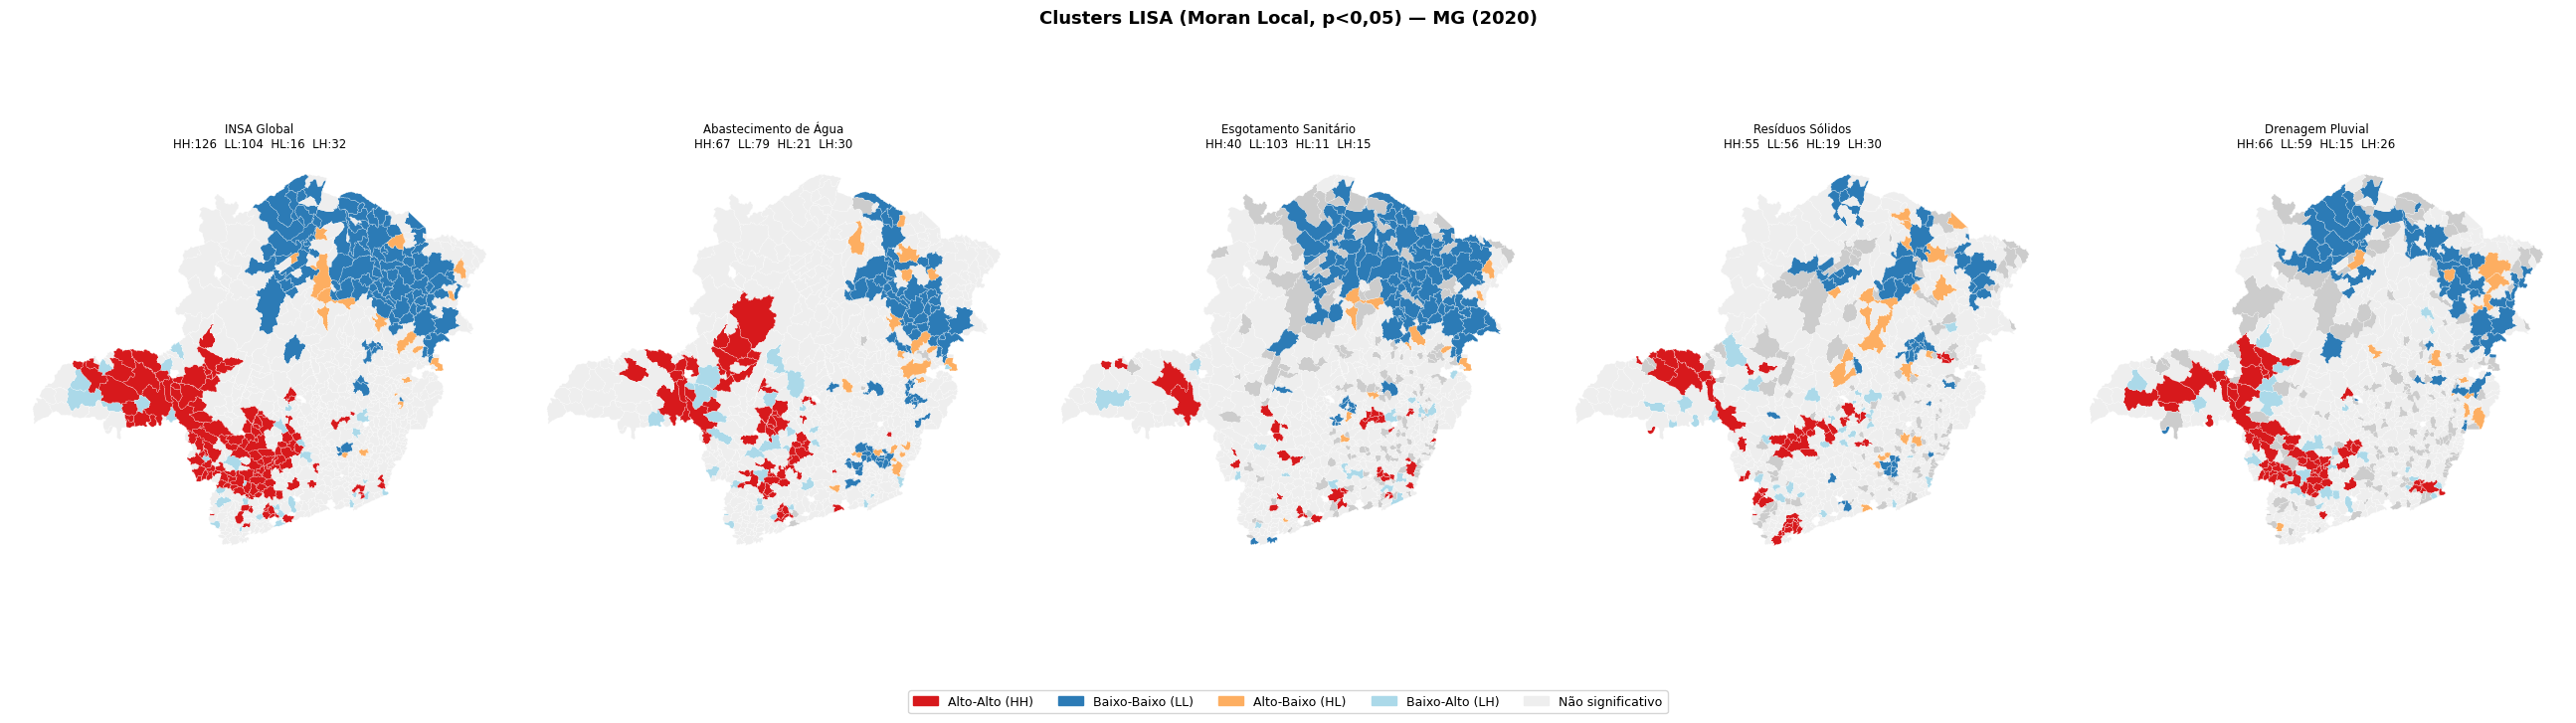

In [15]:
# ── 17. LISA — Moran Local (INSA e Sub-índices) ──────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(26, 7))

cores_lisa = {
    'HH': '#d7191c',   # Alto-Alto
    'LH': '#abd9e9',   # Baixo-Alto
    'LL': '#2c7bb6',   # Baixo-Baixo
    'HL': '#fdae61',   # Alto-Baixo
    'ns': '#eeeeee',   # não significativo
}

for ax, (var, titulo) in zip(axes, variaveis_esp.items()):
    mask = geo_sp[var].notna()
    geo_sub = geo_sp[mask].copy().reset_index(drop=True)
    W_sub = libpysal.weights.Queen.from_dataframe(geo_sub, silence_warnings=True)
    W_sub.transform = 'r'
    y = geo_sub[var].values

    lisa = esda.Moran_Local(y, W_sub, permutations=999)

    # Categorias: 1=HH, 2=LH, 3=LL, 4=HL
    labels = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
    geo_sub['lisa_cat'] = [
        labels.get(q, 'ns') if p < 0.05 else 'ns'
        for q, p in zip(lisa.q, lisa.p_sim)
    ]
    geo_sub['lisa_cor'] = geo_sub['lisa_cat'].map(cores_lisa)

    # Municípios sem dados (não estavam em geo_sub)
    geo_sp_full = geo_sp.copy()
    geo_sp_full.loc[mask, 'lisa_cor_tmp'] = geo_sub['lisa_cor'].values
    geo_sp_full['lisa_cor_tmp'] = geo_sp_full['lisa_cor_tmp'].fillna('#cccccc')

    geo_sp_full.plot(color=geo_sp_full['lisa_cor_tmp'], ax=ax,
                     edgecolor='white', linewidth=0.15)

    contagens = geo_sub['lisa_cat'].value_counts()
    ax.set_title(
        f'{titulo}\n'
        f"HH:{contagens.get('HH',0)}  LL:{contagens.get('LL',0)}  "
        f"HL:{contagens.get('HL',0)}  LH:{contagens.get('LH',0)}",
        fontsize=8.5
    )
    ax.axis('off')

# Legenda
legend_patches = [
    mpatches.Patch(color=c, label=l)
    for l, c in [('Alto-Alto (HH)', '#d7191c'), ('Baixo-Baixo (LL)', '#2c7bb6'),
                 ('Alto-Baixo (HL)', '#fdae61'), ('Baixo-Alto (LH)', '#abd9e9'),
                 ('Não significativo', '#eeeeee')]
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Clusters LISA (Moran Local, p<0,05) — MG (2020)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
